# What the derived state is for

`RDFSimulator` extracts every agent's every field after each tick. It deliberately does not
decide what to compute from it. This notebook is the other half: the three things you
actually do with the extracted state, in the order you need them.

| you want | you use | shown in |
|---|---|---|
| telemetry for calibration or JAX | `sim.fit_iter()` | §3 |
| statistics over per-agent state | polars over `pl.concat(sim.fit_iter())` | §1–2 |
| to stop a bad run early | `break` | §4 |

Nothing below names a column for skabm to collect, and nothing is declared to it: what to
compute is polars.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import polars_random as pr
from maplib import Model

from skabm.behaviour.firm import ownership
from skabm.behaviour.household import initial
from skabm.simulation import RDFSimulator
from skabm import template  # + DataFrame.with_iri

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

N_FIRMS, N_HOUSEHOLDS, N_PERIODS = 40, 400, 24

# The only heterogeneity seeded is the wage. Everything downstream of it -- who earns
# what, who accumulates -- is produced by the rules. The per-sampler `seed=` is what
# makes this reproducible: polars-random's global seed does not reach expressions.
firms = pl.DataFrame({"id": [f"firm_{i}" for i in range(N_FIRMS)]}).with_columns(
    output=pl.lit(100.0), price=pl.lit(1.0), alpha=pl.lit(12.0), size=pl.lit(10.0),
    margin=pl.lit(0.15), liquidity=pl.lit(50.0), profit=pl.lit(5.0),
    w_bar=pr.normal(mean=3.4, std=0.55, seed=11).exp(),
)

# No `wealth` and no `income` column: `household.initial` derives both before the run,
# the second in proportion to the first.
households = pl.DataFrame({
    "id": [f"hh_{i}" for i in range(N_HOUSEHOLDS)],
    "psi": [0.9] * N_HOUSEHOLDS,
    "employer": [f"firm_{i % N_FIRMS}" for i in range(N_HOUSEHOLDS)],
})

PARAMS = {"growth_sigma": 0.04, "total_deposits": 4.0e5}


def economy(hh: pl.DataFrame) -> Model:
    """The opening graph, fresh per call: a fit advances the model it is given."""
    world = Model()
    world.map(template.firm, firms.with_iri())
    owned = initial(ownership(hh, firms, ratio=0.1), firms, **PARAMS)  # firm j -> hh 10 j
    world.map(template.household, owned.with_iri("employer", "owns"))
    return world


def run(hh: pl.DataFrame) -> tuple[RDFSimulator, pl.DataFrame, pl.DataFrame]:
    """Fit: every agent after every tick (the panel), and the aggregate series (the
    telemetry)."""
    sim = RDFSimulator(n_periods=N_PERIODS, random_seed=0, params=PARAMS)
    panel = pl.concat(sim.fit_iter(economy(hh)))
    telemetry = panel.group_by("t", maintain_order=True).agg(
        wealth=pl.col("wealth").sum(), output=pl.col("output").sum()
    )
    return sim, telemetry, panel


sim, telemetry, panel = run(households)
print(f"telemetry {telemetry.shape}, panel {panel.shape}")
print(f"  panel columns: {panel.columns}")

telemetry (24, 3), panel (10560, 16)
  panel columns: ['agent', 'class', 'alpha', 'employer', 'income', 'liquidity', 'margin', 'output', 'owns', 'price', 'profit', 'psi', 'size', 'w_bar', 'wealth', 't']


## 1 — Gini, as a single polars expression

Gini is a property of the *distribution*, so no aggregate skabm derives could be composed into
it. But it is one expression:

$$G = \frac{2 \sum_i i \cdot x_i}{n \sum_i x_i} - \frac{n+1}{n} \qquad (x \text{ sorted ascending},\; i = 1 \ldots n)$$

Written as a `pl.Expr` rather than a function over a Series, it composes like any other
aggregate — it works inside `group_by().agg()`, inside `over()`, and lazily. That is what lets
every tick be computed in one pass instead of a Python loop.

In [2]:
def gini(column: str) -> pl.Expr:
    """Gini coefficient of a non-negative column, as a composable expression."""
    x = pl.col(column).drop_nulls().sort()
    n = x.len()
    return 2 * (pl.int_range(1, n + 1, dtype=pl.Int64) * x).sum() / (n * x.sum()) - (n + 1) / n


# One grouped pass over the whole panel: every tick's Gini, no Python loop.
inequality = (
    panel.lazy()
    .group_by("t")
    .agg(gini("wealth").alias("gini"), pl.col("wealth").mean().alias("mean_wealth"))
    .sort("t")
    .collect()
)
inequality.head()

t,gini,mean_wealth
i32,f64,f64
1,0.28088,1007.615951
2,0.28088,1015.231901
3,0.28088,1022.847852
4,0.28088,1030.463803
5,0.28088,1038.079753


### The result is exactly flat — and that is the finding

Wealth grows every quarter, but the Gini does not move at all. That is not a bug in the
measurement; it is a property of the model as specified.

`household.initial` sets opening wealth *proportional to income*, and `poledna_consume`
saves a fixed fraction `psi` of income. So each household's wealth stays a fixed multiple of its
income for all time: the distribution is rescaled every tick, never reshaped. A scale-invariant
distribution has a constant Gini.

Worth noticing what it took to see this: no metric was declared, and the flatness is visible in
the first four rows.

Gini 0.2809 -> 0.2809 while mean wealth 1008 -> 1183


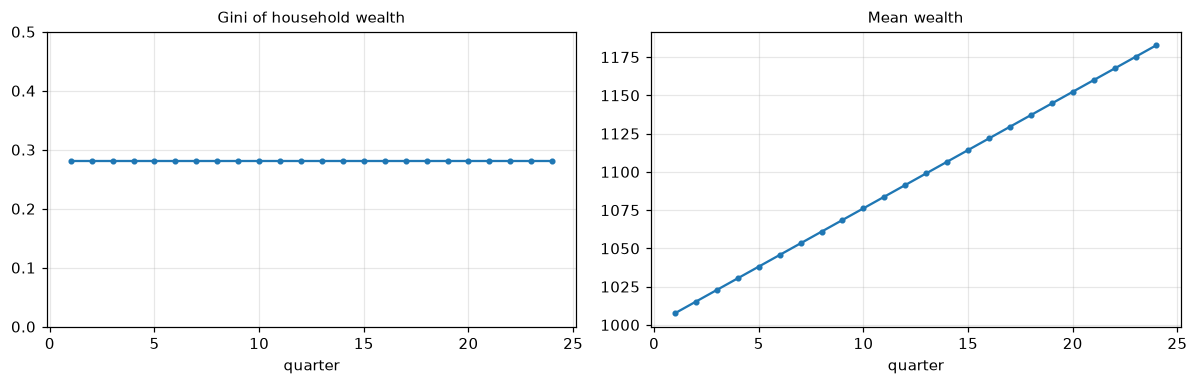

In [3]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.6))
left.plot(inequality["t"], inequality["gini"], marker="o", ms=3)
left.set_title("Gini of household wealth", fontsize=10)
left.set_ylim(0, 0.5); left.set_xlabel("quarter")

right.plot(inequality["t"], inequality["mean_wealth"], marker="o", ms=3)
right.set_title("Mean wealth", fontsize=10); right.set_xlabel("quarter")
fig.tight_layout()

print(f"Gini {inequality['gini'][0]:.4f} -> {inequality['gini'][-1]:.4f} "
      f"while mean wealth {inequality['mean_wealth'][0]:.0f} -> {inequality['mean_wealth'][-1]:.0f}")

## 2 — Give it a mechanism, and it moves

Scale invariance breaks the moment the savings rate stops being uniform. Tie `psi` to the wage —
higher earners save a larger share — and wealth stops tracking income proportionally.

`psi` is an agent attribute, not a parameter, so this is a change to the *population*, not to the
rules. Nothing about the simulator call changes.

uniform  0.2809 -> 0.2809
gradient 0.2818 -> 0.2997


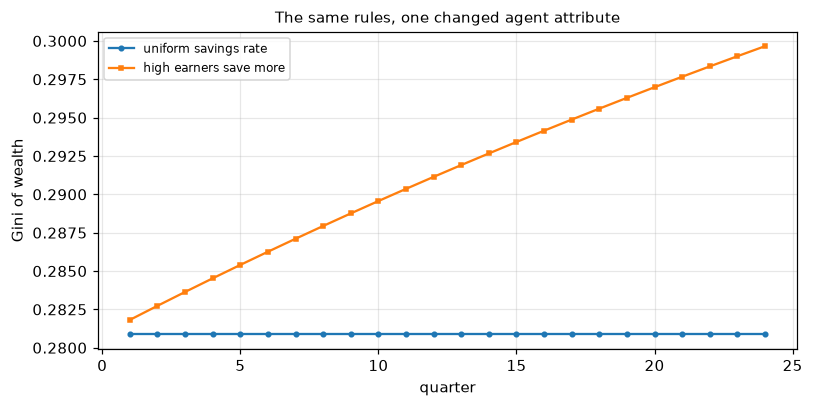

In [4]:
wages = pl.DataFrame({"employer": firms["id"], "w": firms["w_bar"]})
saving_gradient = households.join(wages, on="employer").with_columns(
    # psi is the propensity to *consume*, so a lower psi means a higher savings rate
    psi=0.98 - 0.25 * (pl.col("w") - pl.col("w").min()) / (pl.col("w").max() - pl.col("w").min())
).drop("w")

_, _, panel_gradient = run(saving_gradient)
gradient = (
    panel_gradient.lazy()
    .group_by("t")
    .agg(gini("wealth").alias("gini"))
    .sort("t")
    .collect()
)

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(inequality["t"], inequality["gini"], marker="o", ms=3, label="uniform savings rate")
ax.plot(gradient["t"], gradient["gini"], marker="s", ms=3, label="high earners save more")
ax.set_xlabel("quarter"); ax.set_ylabel("Gini of wealth"); ax.legend(fontsize=8)
ax.set_title("The same rules, one changed agent attribute", fontsize=10)
fig.tight_layout()

print(f"uniform  {inequality['gini'][0]:.4f} -> {inequality['gini'][-1]:.4f}")
print(f"gradient {gradient['gini'][0]:.4f} -> {gradient['gini'][-1]:.4f}")

## 3 — The telemetry side: the yielded rows into JAX

`fit_iter` yields every agent after each tick, and `telemetry` is two sums over it: one
`group_by("t")` gives one row per tick, one column per series, the plain numeric
table `polars.DataFrame.to_jax` wants, with no database in the path and no pivot. From there it is somebody else's library: a differentiable loss
over simulated-versus-observed series, gradient-based calibration on summary statistics, a neural
surrogate.

Note the boundary. The gradient below is with respect to the *loss over recorded series*, not
through the tick — a tick is a sequence of SPARQL round trips and nothing traces through it.

In [5]:
print(f"{telemetry.width - 1} series x {telemetry.height} ticks")

series = telemetry.select("wealth", "output")
arr = series.to_jax()          # (ticks, 2) float32
print("\nto_jax ->", arr.shape, arr.dtype)

# Standardise before fitting. The raw series is O(1e5), so an unnormalised squared
# loss overflows on the first gradient step -- and centring makes scale and shift
# identifiable instead of nearly collinear. Calibration does both anyway.
wealth = arr[:, 0]
simulated = (wealth - wealth.mean()) / wealth.std()

# A toy objective: recover a known scale-and-shift of the simulated series. The
# point is the plumbing, not the economics.
target = simulated * 1.5 + 0.2


def loss(theta):
    scale, shift = theta
    return jnp.mean((simulated * scale + shift - target) ** 2)


theta = jnp.array([1.0, 0.0])
for _ in range(500):
    theta = theta - 0.1 * jax.grad(loss)(theta)

print(f"\nrecovered scale={theta[0]:.4f} shift={theta[1]:.4f}  (true 1.5000 / 0.2000)")
print(f"final loss {loss(theta):.3e}")

2 series x 24 ticks

to_jax -> (24, 2) float32



recovered scale=1.5000 shift=0.2000  (true 1.5000 / 0.2000)
final loss 6.496e-14


## 4 — Calibration, on the statistics you choose

A parameter search wants a fixed `(N, D)` array of per-tick summary statistics from every
candidate. Which statistics is a modelling choice, so `simulator_model` takes them as
`summarise`: one tick's frame to the numbers, in polars.

In [6]:
import time
from functools import partial

from flax.training.early_stopping import EarlyStopping

from skabm.calibration import simulator_model

BASELINE = partial(economy, households)   # a fresh world per candidate

def summarise(state: pl.DataFrame) -> tuple:
    """One tick -> the numbers a loss compares: aggregate wealth and output, the price level."""
    return state.select(
        pl.col("wealth").sum(),
        pl.col("output").sum(),
        pl.col("price").filter(pl.col("class") == "Firm").mean(),
    ).row(0)


model = simulator_model(BASELINE, free=["growth_sigma"], summarise=summarise, params=PARAMS)
out = model([0.02], 60, seed=0)
print(f"{out.shape} — {model.ticks_} ticks x {out.shape[1]} statistics")

(60, 3) — 60 ticks x 3 statistics


A distributional statistic, like the Gini above, goes in the same way.

## 5 — Early stopping, with flax

A search spends most of its time on candidates that were never going to fit, and on ticks
after a run has settled. `simulator_model` takes a `stop=` callable and handles the
mechanics — a stopped run is padded back to `(N, D)` by carrying the last row forward, so
the contract holds and the loss stays finite.

skabm ships **no criterion**, and does not need to: `flax.training.early_stopping.EarlyStopping`
is exactly this algorithm, with `min_delta` and `patience` and a tested notion of "has this
improved". All we supply is the metric it watches — here the largest relative change across
the summary statistics from one tick to the next, which falls as a run settles.

In [7]:
def settled(patience: int, min_delta: float = 1e-3):
    """A `stop=` callable backed by flax. It owns the rule; we own the metric."""
    state = EarlyStopping(min_delta=min_delta, patience=patience)

    def stop(rows: list[list[float]]) -> bool:
        nonlocal state
        if len(rows) < 2:
            return False
        previous, current = np.asarray(rows[-2]), np.asarray(rows[-1])
        drift = float(np.max(np.abs(current - previous) / (np.abs(previous) + 1e-12)))
        state = state.update(drift)
        return bool(state.should_stop)

    return stop


print(f"{'patience':<10} {'sigma=0.0 (settles)':<22} {'sigma=0.04 (shocked)':<22} saving")
for patience in (3, 10, 25, None):
    ran, elapsed = [], []
    for sigma in (0.0, 0.04):
        stop = settled(patience) if patience else None
        candidate = simulator_model(
            BASELINE, free=["growth_sigma"], summarise=summarise, params=PARAMS, stop=stop
        )
        start = time.time()
        result = candidate([sigma], 120, seed=0)
        assert result.shape == (120, 3)   # contract held
        ran.append(candidate.ticks_)
        elapsed.append(time.time() - start)
    label = f"{patience}" if patience else "no stop"
    print(f"{label:<10} {ran[0]:>3}/120 in {elapsed[0]:>5.2f}s      "
          f"{ran[1]:>3}/120 in {elapsed[1]:>5.2f}s      {sum(elapsed):.2f}s total")

patience   sigma=0.0 (settles)    sigma=0.04 (shocked)   saving


3            6/120 in  0.78s        6/120 in  0.80s      1.58s total


10          13/120 in  1.34s       13/120 in  1.36s      2.70s total


25          49/120 in  3.93s       50/120 in  4.02s      7.94s total


no stop    120/120 in  9.33s      120/120 in  9.09s      18.43s total


Every row is a valid `(120, D)` array, so any of these drops into black-it unchanged, and
`model.ticks_` says how far each candidate actually got.

**Read the semantics before trusting it.** flax stops when the metric has not *improved*
for `patience` steps. For a settling run that means convergence. For a stochastic one it
means the run has stopped settling *further* — it has reached its ergodic distribution,
and more ticks resample it rather than telling you anything new. That is the right stop if
your loss is on steady-state moments, and the wrong one if it is on the transition path,
which is why `patience` is a dial and not a default. A criterion that fires too eagerly
silently truncates good runs, which is worse than slow ones.

One thing genuinely unavailable to judge on: the *learning* trajectory. History rules
upsert their results, so the graph carries one current forecast, and the telemetry holds
the agents, not the forecasts. Watching a forecast fail to converge would be a better
signal, and it is not currently recorded.

## Where the line is

Four things happened above, and skabm did one and a half of them.

- **It extracted every field.** `panel.columns` came off the graph; none was written down.
- **It did not compute Gini.** No rule mentions one, and it cannot be composed from
  class-level scalars. Four lines of polars, and it belongs to whoever is asking.
- **It did not touch JAX.** The telemetry frame is the handover point.
- **It did not decide when to stop** — flax did. skabm supplies the seam and the padding,
  because the `(N, D)` contract is not optional; the rule is a well-tested library's.

skabm hands over every agent after every tick, in the shape the ecosystem already takes.
Choosing the series, doing statistics on the distribution, and judging when a run has gone
bad stay with the researcher and their libraries, which is the right place for a modelling
claim to live.